In [13]:
import time

Function definition

In [1]:
from joblib import Parallel, delayed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ML_predictor import MLPredictorStrategy
from src.backtest.vector_backtester import PortfolioVectorEngine

def run_grid_case(symbol, start_date =  "2018-01-01", end_date = "2019-01-01", n_features = 6, signal_threshold = 0.001, training_years = 5, position_size = 1.00, initial_capital = 1000000, verbose = False, show_progress=False):
    params = {
        "symbol": symbol,
        "start_date": start_date,
        "end_date": end_date,
        "signal_threshold": signal_threshold,
        "n_features": n_features,
        "position_size": position_size,
        "training_years": training_years,
        "max_iter": 5000,
        "verbose": verbose
    }

    strategy = MLPredictorStrategy(params=params)
    dataset = strategy.prepare_dataset()
    weights = strategy.generate_signals(dataset, show_progress=show_progress)

    if weights.empty:
        return None

    prices_run = dataset[["Open"]].rename(columns={"Open": symbol}).loc[weights.index]

    engine_run = PortfolioVectorEngine(
        prices=prices_run,
        signals=weights,
        asset_class="STK",
        initial_capital=initial_capital,
        execution_delay=0,
    )

    stats_run = engine_run.run()

    return {
        **params,
        "net_return_pct": (stats_run["net_equity"].iloc[-1] / initial_capital - 1) * 100,
        "gross_return_pct": (stats_run["gross_equity"].iloc[-1] / initial_capital - 1) * 100,
        "final_net_equity": stats_run["net_equity"].iloc[-1],
        "final_gross_equity": stats_run["gross_equity"].iloc[-1],
    }


Non-parallelised

,symbol,start_date,end_date,signal_threshold,n_features,position_size,training_years,max_iter,verbose,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2018-01-01,2019-01-01,0.002,3,1.0,1,5000,False,4.726053,6.230437,1.047261e+06,1.062304e+06
1,ECH,2018-01-01,2019-01-01,0.002,3,1.0,2,5000,False,203.461990,211.265706,3.034620e+06,3.112657e+06
2,ECH,2018-01-01,2019-01-01,0.002,3,1.0,3,5000,False,260.802337,270.556489,3.608023e+06,3.705565e+06
3,ECH,2018-01-01,2019-01-01,0.002,3,1.0,4,5000,False,294.673790,305.379641,3.946738e+06,4.053796e+06
4,ECH,2018-01-01,2019-01-01,0.002,3,1.0,5,5000,False,383.284127,395.364411,4.832841e+06,4.953644e+06


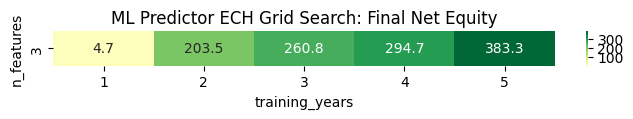

Total execution time: 5m 6s


In [15]:
start_time = time.time()

symbol = "ECH"
training_years_list = [1, 2, 3, 4, 5]
n_features_list = [3]

grid_records = []

for n_features in n_features_list:
    for training_years in training_years_list:
        
        grid_records.append(run_grid_case(symbol=symbol, n_features=n_features, training_years=training_years, signal_threshold=0.002, start_date="2018-01-01", end_date="2019-01-01"))

grid_records = [record for record in grid_records if record is not None]

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="training_years", values="net_return_pct")

display(grid_df.sort_values(["n_features", "training_years"]).reset_index(drop=True))

plt.figure(figsize=(1.4*len(grid_pivot.columns), 1.3*len(grid_pivot.index)))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Final Net Equity")
plt.xlabel("training_years")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

end_time = time.time()
elapsed_time = round(end_time - start_time)
if elapsed_time > 60:
    elapsed_time_str = f"{int(elapsed_time//60)}m {elapsed_time%60}s"
else:
    elapsed_time_str = f"{elapsed_time:.1f}s"

print(f"Total execution time: {elapsed_time_str}")


`threading` and `n_jobs=-1`

,symbol,start_date,end_date,signal_threshold,n_features,position_size,training_years,max_iter,verbose,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2018-01-01,2019-01-01,0.002,3,1.0,1,5000,False,-0.231110,1.581593,9.976889e+05,1.015816e+06
1,ECH,2018-01-01,2019-01-01,0.002,3,1.0,2,5000,False,203.461990,211.265706,3.034620e+06,3.112657e+06
2,ECH,2018-01-01,2019-01-01,0.002,3,1.0,3,5000,False,147.932457,153.702120,2.479325e+06,2.537021e+06
3,ECH,2018-01-01,2019-01-01,0.002,3,1.0,4,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06
4,ECH,2018-01-01,2019-01-01,0.002,3,1.0,5,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06


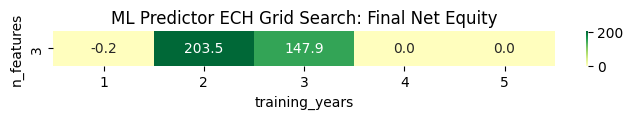

Total execution time: 3m 22s


In [16]:
start_time = time.time()

symbol = "ECH"
training_years_list = [1, 2, 3, 4, 5]
n_features_list = [3]

cases = [
    (n_features, training_years)
    for n_features in n_features_list
    for training_years in training_years_list
]

grid_records = Parallel(n_jobs=-1, backend="threading")(
    delayed(run_grid_case)(symbol=symbol, n_features=n_features, training_years=training_years, signal_threshold=0.002, start_date="2018-01-01", end_date="2019-01-01")
    for n_features, training_years in cases
)

grid_records = [record for record in grid_records if record is not None]

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="training_years", values="net_return_pct")

display(grid_df.sort_values(["n_features", "training_years"]).reset_index(drop=True))

plt.figure(figsize=(1.4*len(grid_pivot.columns), 1.3*len(grid_pivot.index)))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Final Net Equity")
plt.xlabel("training_years")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

end_time = time.time()
elapsed_time = round(end_time - start_time)
if elapsed_time > 60:
    elapsed_time_str = f"{int(elapsed_time//60)}m {elapsed_time%60}s"
else:
    elapsed_time_str = f"{elapsed_time:.1f}s"

print(f"Total execution time: {elapsed_time_str}")


`threading` and `n_jobs=4`

,symbol,start_date,end_date,signal_threshold,n_features,position_size,training_years,max_iter,verbose,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2018-01-01,2019-01-01,0.002,3,1.0,1,5000,False,4.726053,6.230437,1.047261e+06,1.062304e+06
1,ECH,2018-01-01,2019-01-01,0.002,3,1.0,2,5000,False,166.652953,173.143050,2.666530e+06,2.731431e+06
2,ECH,2018-01-01,2019-01-01,0.002,3,1.0,3,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06
3,ECH,2018-01-01,2019-01-01,0.002,3,1.0,4,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06
4,ECH,2018-01-01,2019-01-01,0.002,3,1.0,5,5000,False,383.284127,395.364411,4.832841e+06,4.953644e+06


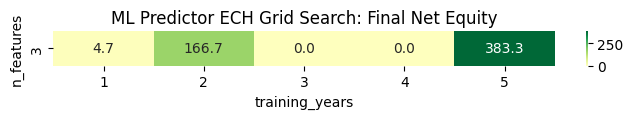

Total execution time: 4m 26s


In [17]:
start_time = time.time()

symbol = "ECH"
training_years_list = [1, 2, 3, 4, 5]
n_features_list = [3]

cases = [
    (n_features, training_years)
    for n_features in n_features_list
    for training_years in training_years_list
]

grid_records = Parallel(n_jobs=4, backend="threading")(
    delayed(run_grid_case)(symbol=symbol, n_features=n_features, training_years=training_years, signal_threshold=0.002, start_date="2018-01-01", end_date="2019-01-01")
    for n_features, training_years in cases
)

grid_records = [record for record in grid_records if record is not None]

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="training_years", values="net_return_pct")

display(grid_df.sort_values(["n_features", "training_years"]).reset_index(drop=True))

plt.figure(figsize=(1.4*len(grid_pivot.columns), 1.3*len(grid_pivot.index)))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Final Net Equity")
plt.xlabel("training_years")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

end_time = time.time()
elapsed_time = round(end_time - start_time)
if elapsed_time > 60:
    elapsed_time_str = f"{int(elapsed_time//60)}m {elapsed_time%60}s"
else:
    elapsed_time_str = f"{elapsed_time:.1f}s"

print(f"Total execution time: {elapsed_time_str}")


`loky` and `n_jobs=-1`

,symbol,start_date,end_date,signal_threshold,n_features,position_size,training_years,max_iter,verbose,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2018-01-01,2019-01-01,0.002,3,1.0,1,5000,False,4.726002,6.230386,1.047260e+06,1.062304e+06
1,ECH,2018-01-01,2019-01-01,0.002,3,1.0,2,5000,False,203.460359,211.264049,3.034604e+06,3.112640e+06
2,ECH,2018-01-01,2019-01-01,0.002,3,1.0,3,5000,False,260.803450,270.557635,3.608035e+06,3.705576e+06
3,ECH,2018-01-01,2019-01-01,0.002,3,1.0,4,5000,False,294.674635,305.380488,3.946746e+06,4.053805e+06
4,ECH,2018-01-01,2019-01-01,0.002,3,1.0,5,5000,False,383.284067,395.364349,4.832841e+06,4.953643e+06


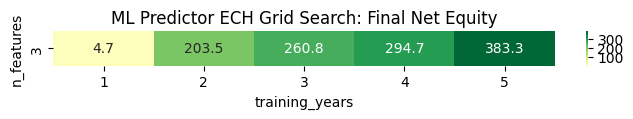

Total execution time: 2m 56s


In [18]:
start_time = time.time()

symbol = "ECH"
training_years_list = [1, 2, 3, 4, 5]
n_features_list = [3]

cases = [
    (n_features, training_years)
    for n_features in n_features_list
    for training_years in training_years_list
]

grid_records = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_grid_case)(symbol=symbol, n_features=n_features, training_years=training_years, signal_threshold=0.002, start_date="2018-01-01", end_date="2019-01-01")
    for n_features, training_years in cases
)

grid_records = [record for record in grid_records if record is not None]

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="training_years", values="net_return_pct")

display(grid_df.sort_values(["n_features", "training_years"]).reset_index(drop=True))

plt.figure(figsize=(1.4*len(grid_pivot.columns), 1.3*len(grid_pivot.index)))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Final Net Equity")
plt.xlabel("training_years")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

end_time = time.time()
elapsed_time = round(end_time - start_time)
if elapsed_time > 60:
    elapsed_time_str = f"{int(elapsed_time//60)}m {elapsed_time%60}s"
else:
    elapsed_time_str = f"{elapsed_time:.1f}s"

print(f"Total execution time: {elapsed_time_str}")


`loky` and `n_jobs=4`

,symbol,start_date,end_date,signal_threshold,n_features,position_size,training_years,max_iter,verbose,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2018-01-01,2019-01-01,0.002,3,1.0,1,5000,False,4.725959,6.230343,1.047260e+06,1.062303e+06
1,ECH,2018-01-01,2019-01-01,0.002,3,1.0,2,5000,False,203.461056,211.264757,3.034611e+06,3.112648e+06
2,ECH,2018-01-01,2019-01-01,0.002,3,1.0,3,5000,False,260.805438,270.559639,3.608054e+06,3.705596e+06
3,ECH,2018-01-01,2019-01-01,0.002,3,1.0,4,5000,False,294.673497,305.379354,3.946735e+06,4.053794e+06
4,ECH,2018-01-01,2019-01-01,0.002,3,1.0,5,5000,False,383.282604,395.362858,4.832826e+06,4.953629e+06


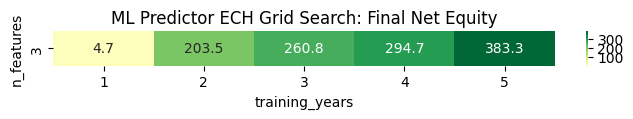

Total execution time: 3m 31s


In [19]:
start_time = time.time()

symbol = "ECH"
training_years_list = [1, 2, 3, 4, 5]
n_features_list = [3]

cases = [
    (n_features, training_years)
    for n_features in n_features_list
    for training_years in training_years_list
]

grid_records = Parallel(n_jobs=4, backend="loky")(
    delayed(run_grid_case)(symbol=symbol, n_features=n_features, training_years=training_years, signal_threshold=0.002, start_date="2018-01-01", end_date="2019-01-01")
    for n_features, training_years in cases
)

grid_records = [record for record in grid_records if record is not None]

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="training_years", values="net_return_pct")

display(grid_df.sort_values(["n_features", "training_years"]).reset_index(drop=True))

plt.figure(figsize=(1.4*len(grid_pivot.columns), 1.3*len(grid_pivot.index)))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Final Net Equity")
plt.xlabel("training_years")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

end_time = time.time()
elapsed_time = round(end_time - start_time)
if elapsed_time > 60:
    elapsed_time_str = f"{int(elapsed_time//60)}m {elapsed_time%60}s"
else:
    elapsed_time_str = f"{elapsed_time:.1f}s"

print(f"Total execution time: {elapsed_time_str}")


CONCLUSION:

`locky` performs correctly (ie same as non-parallelised) for both cases of `n_jobs` = -1 or 4.

It is 16% faster with `n_jobs = -1` (2m 56s) than with `n_jobs = 4` (3m 31s). The non-parallelised run took 5m 6s (74% more time).

`threading` performs incorrectly >50% of the iterations – totally unrelaible. Note that `n_jobs = -1` is faster than `n_jobs = 4` similarly to `locky`.